<a href="https://colab.research.google.com/github/Dferrer2405/Prueba-tecnica-naowee--Daniel-Ferrer/blob/main/Caso_2_Prueba_T%C3%A9cnica_Daniel_Ferrer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [178]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from sklearn.metrics import (
    classification_report, roc_auc_score,
    RocCurveDisplay, confusion_matrix,
    ConfusionMatrixDisplay
)
df=pd.read_csv("/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn


In [179]:
#PERFILADO

#Forma de df
print('El dataframe cuenta con',df.shape[0],'observaciones y',
      df.shape[1],'variables')
print('')
#Resumen de datos
resumen = pd.DataFrame({
    "dtype_pandas": df.dtypes,
    "n_unicos": df.nunique(),
    "ejemplo": df.iloc[0]
})
print('PERFIL DE VARIABLES')
print(resumen)
print()

#Conteo de nulos y %
print('VALORES NULOS Y DUPLICADOS')
nulo=pd.DataFrame({'n_null':df.isnull().sum(),
                   'pct_null':df.isnull().sum()/df.shape[0]
                  })
if nulo[nulo['n_null']!=0].empty:
    print('1. No hay variables con nulos')
else:
    print(nulo[nulo['n_null']!=0].sort_values('n_null',ascending=False))

#Conteo de duplicados
duplicados=df.duplicated().sum()
if duplicados==0:
    print('2. No hay observaciones duplicadas')
else:
    print('Hay',duplicados,'duplicados')

El dataframe cuenta con 7043 observaciones y 21 variables

PERFIL DE VARIABLES
                 dtype_pandas  n_unicos           ejemplo
customerID             object      7043        7590-VHVEG
gender                 object         2            Female
SeniorCitizen           int64         2                 0
Partner                object         2               Yes
Dependents             object         2                No
tenure                  int64        73                 1
PhoneService           object         2                No
MultipleLines          object         3  No phone service
InternetService        object         3               DSL
OnlineSecurity         object         3                No
OnlineBackup           object         3               Yes
DeviceProtection       object         3                No
TechSupport            object         3                No
StreamingTV            object         3                No
StreamingMovies        object         3            

In [180]:
#TRANSFORMACIONES

#1. Total charges como string
print("1.MODIFICACIÓN TOTAL CHARGES")
print(f"\nTotal charges en blanco: {(df['TotalCharges'] == ' ').sum()}")

#Forzar como numerico
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
total_charge_blancos=df[df['TotalCharges'].isnull()]

#Perfilamiento de total charges nulos
print(total_charge_blancos[['tenure','MonthlyCharges','TotalCharges']])
print(total_charge_blancos["tenure"].unique())
print()
print()

#fill nulos
df["TotalCharges"]=df["TotalCharges"].fillna(0)

#2. Categorías 'no internet service' y 'no phone service'
print("2.CATEGORIAS NO INTERNET/PHONE  SERVICE")
cols_servicio = [
    "MultipleLines", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"
]

print('Categorias antes de modificación')
for col in cols_servicio:
    print(f"{col}: {df[col].unique()}")

print()
 #Relación de no internet/phone service con variable no phone/internet service
print('Valores unicos de variables de servicio cuando internet/phone service = NO')
print(df[df["OnlineSecurity"] == "No internet service"]["InternetService"].unique())
print(df[df["MultipleLines"] == "No phone service"]["PhoneService"].unique())
print()
  #Colapso a binarios
for col in cols_servicio:
    df[col] = df[col].replace({
        "No internet service": "No",
        "No phone service":    "No"
    })

print('Categorias despues de modificación')
for col in cols_servicio:
    print(f"{col}: {df[col].unique()}")

#3. Categorías de variable senior citizen
print()
print()
print('3.VARIABLE SENIOR CITIZEN')
print('Categorias antes de modificación')
print(df['SeniorCitizen'].unique())

df['SeniorCitizen'] = df['SeniorCitizen'].replace({
    0: "No",
    1: "Yes"
})

print()
print('Categorias despues de modificación')
print(df['SeniorCitizen'].unique())
print()
print()

#4. Binarizar Churn
print()
print()
print('4.VARIABLE OBJETIVO CHURN')
print('Categorias antes de modificación')
print(df['Churn'].value_counts())

df['Churn'] = df['Churn'].replace({
    "No": 0,
    "Yes": 1
})

print()
print('Categorias despues de modificación')
print(df['Churn'].value_counts())
print()
print()

#5. Checkeo de nulos y duplicados residuales
customer_id=df['customerID'].copy()
df.drop(columns='customerID')

print('5.VALORES NULOS Y DUPLICADOS RESIDUALES')
  #Duplicados
print("Duplicados exactos:", df.duplicated().sum())

  #Nulos
nulos_finales = df.isnull().sum()
print("Nulos exactos:",nulos_finales[nulos_finales > 0].shape[0])



1.MODIFICACIÓN TOTAL CHARGES

Total charges en blanco: 11
      tenure  MonthlyCharges  TotalCharges
488        0           52.55           NaN
753        0           20.25           NaN
936        0           80.85           NaN
1082       0           25.75           NaN
1340       0           56.05           NaN
3331       0           19.85           NaN
3826       0           25.35           NaN
4380       0           20.00           NaN
5218       0           19.70           NaN
6670       0           73.35           NaN
6754       0           61.90           NaN
[0]


2.CATEGORIAS NO INTERNET/PHONE  SERVICE
Categorias antes de modificación
MultipleLines: ['No phone service' 'No' 'Yes']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['No' 'Yes' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']

/tmp/ipykernel_2785/3076656492.py:73: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Churn'] = df['Churn'].replace({


In [181]:
#RESUMEN DE PERFIL
resumen_final = pd.DataFrame({
    "dtype_pandas":   df.dtypes,
    "n_nulos":        df.isnull().sum(),
    "n_unicos":       df.nunique(),
    "ejemplo_val":    df.iloc[0],
})

#Categoría semantica
Categoria_semantica=[]
for index, row in resumen_final.iterrows():
  if row['dtype_pandas'] == 'object':
    if row['n_unicos'] == 2:
      Categoria_semantica.append('Categorica Binaria')
    else:
      Categoria_semantica.append('Categorica Nominal')
  elif row['dtype_pandas'] == 'int64':
    Categoria_semantica.append('Numerica Discreta')
  else:
    Categoria_semantica.append('Numerica Continua')

resumen_final['Categoria_semantica']=Categoria_semantica

#Ajuste clasificaciones erroneas
resumen_final.loc[resumen_final.index[2], 'Categoria_semantica'] = 'Categorica Binaria'
resumen_final.loc[resumen_final.index[19], 'Categoria_semantica'] = 'Numerica Continua'

print(resumen_final)

                 dtype_pandas  n_nulos  n_unicos       ejemplo_val  \
customerID             object        0      7043        7590-VHVEG   
gender                 object        0         2            Female   
SeniorCitizen          object        0         2                No   
Partner                object        0         2               Yes   
Dependents             object        0         2                No   
tenure                  int64        0        73                 1   
PhoneService           object        0         2                No   
MultipleLines          object        0         2                No   
InternetService        object        0         3               DSL   
OnlineSecurity         object        0         2                No   
OnlineBackup           object        0         2               Yes   
DeviceProtection       object        0         2                No   
TechSupport            object        0         2                No   
StreamingTV         

In [182]:
print('TABLA DE DECISIONES')
print()
decisiones = pd.DataFrame({
    "Variable / problema": [
        "TotalCharges (string)",
        "TotalCharges nulos (11 registros)",
        "No internet/phone service",
        "SeniorCitizen (0/1)",
        "Churn (Yes/No)",
        "customerID",
        "Duplicados",
        "Nulos"
    ],
    "Decisión": [
        "Convertir a float con pd.to_numeric(errors='coerce')",
        "Imputar con 0",
        "Colapsar a binario'",
        "Homogeneizar a Yes/No",
        "Binarizar: Yes → 1, No → 0",
        "Excluir del dataset de modelado",
        "Ninguno encontrado",
        "Ninguno encontrado"
    ],
    "Justificación": [
        "El tipo original impide operaciones numéricas",
        "tenure == 0 → sin ciclo de facturación completo, cero es correcto",
        "La información ya está registrada en otras variables",
        "Consistencia con el resto de binarias del dataset",
        "Requerido para clasificación; 26.5% de positivos",
        "Identificador sin poder predictivo; riesgo de memorización",
        "Dataset limpio de origen",
        "Dataset limpio tras moditransformaciones"
    ]
})
decisiones


TABLA DE DECISIONES



,Variable / problema,Decisión,Justificación
0,TotalCharges (string),Convertir a float con pd.to_numeric(errors='co...,El tipo original impide operaciones numéricas
1,TotalCharges nulos (11 registros),Imputar con 0,tenure == 0 → sin ciclo de facturación complet...
2,No internet/phone service,Colapsar a binario',La información ya está registrada en otras var...
3,SeniorCitizen (0/1),Homogeneizar a Yes/No,Consistencia con el resto de binarias del dataset
4,Churn (Yes/No),"Binarizar: Yes → 1, No → 0",Requerido para clasificación; 26.5% de positivos
5,customerID,Excluir del dataset de modelado,Identificador sin poder predictivo; riesgo de ...
6,Duplicados,Ninguno encontrado,Dataset limpio de origen
7,Nulos,Ninguno encontrado,Dataset limpio tras moditransformaciones


Caso 2 - Parte A
  
  1. Perfilado y limpieza de datos:

    1.1. Identificación de variables y tipo:

      7043 observaciones con 21 variables que se pueden dividir entre 4 clases: Información de servicios del cliente, información demografica del cliente e información demografica del cliente. La mayoría de variables son de tipo categorico y cada observación corresponde a un cliente. La variable "customer ID" actua como identificador unico de cada uno de ellos. Dentro del tipo de variables se observan problemas con la variable "TotalCharges" que está registrada como object en vez de numerica, debería ser un float ya que representa una variable cuantitativa continua. También se tienen problemas con la variable de interes Churn, ya que está registrada como object por sus categorías Yes o No. Esto puede obstaculizar contar a futuro los datos asociados al Churn por lo que será necesario convertirla en int64 o un boolean.
      
      Por ultimo, el dataset no cuenta con variables duplicadas ni nulas, como se puede intuir ya que el numero de observaciones en el dataframe es igual al numero de valores unicos en la variable "customerID" por lo que ninguna fila puede ser exactamente igual.

    1.2 Limpieza y transformaciones

      - Total_Charges: La variable se guarda como object debido a que hay 11 mismatches, 11 observaciones donde las filas no están vacias si no en blanco, es decir ' '. Lo que tienen en común estas observaciones es que el valor de tenure en 0 por lo que corresponde a clientes que no han cumplido su primer ciclo de facturación. Para evitar mantener esta información nula, se llenan con el valor de 0 ya que no han recibido cargos aún.

      - Categorias No internet/phone service: Estas categorías son redundantes, ya que son retipificaciones de la información recogida en las variables "PhoneService" e "InternetService". Por esta razón, es una categoría que en las variables de servicio no aporta información nueva y aumenta la granularidad de las variables. Con este razonamiento, se decidió colapsar las variables de servicio en binarios, convirtiendo las categorías "No internet/phone service" en "Yes" o "No".

      - Variable senior citizen: Como se mencionó previamente, esta variable es una categorica binaria. Sin embargo, se diferencia del resto de variables categoricas ya que está registrada como int debido a que toma valores de 0 y 1. Con el fin de homogenizarla con el resto de variables categoricas, se reemplazaron los 0 y 1 por "No" y "Yes".

      - Variable objetivo Churn: Al contrario que con la variable anterior se decide convertir las etiquetas de categorización 'Yes' y 'No' a numericos 1 y 0 respectivamente. Esto facilitará el analisis exploratorio e introducción en modelos de regresión.

      - Nulos y Duplicados residuales: No se identifican duplicados ni nulos residuales.


    
    
    

1.TENURE Y ABANDONO
Distribución de tenure en clientes que abandonan
count    1869.000000
mean       17.979133
std        19.531123
min         1.000000
25%         2.000000
50%        10.000000
75%        29.000000
max        72.000000
Name: tenure, dtype: float64



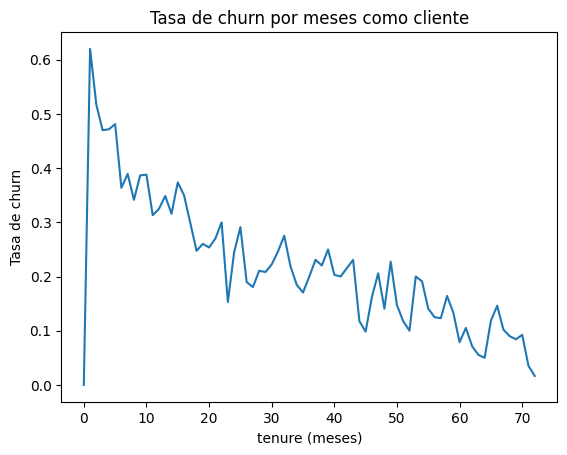


2.CHURN POR TIPO DE CONTRATO
                 mean  count
Contract                    
Month-to-month  0.427   3875
One year        0.113   1473
Two year        0.028   1695

3.CHURN POR GENERO
         mean  count
gender              
Female  0.269   3488
Male    0.262   3555


In [183]:
#Exploración de churn y variables relacionadas

#distribución de churn en clientes churn=1
print('1.TENURE Y ABANDONO')
print('Distribución de tenure en clientes que abandonan')
print(df[df["Churn"] == 1]["tenure"].describe())
print()
# Churn por tenure
churn_por_tenure = (df.groupby("tenure")["Churn"]
    .mean()
    .reset_index())

plt.plot(churn_por_tenure["tenure"], churn_por_tenure["Churn"])
plt.title("Tasa de churn por meses como cliente")
plt.xlabel("tenure (meses)")
plt.ylabel("Tasa de churn")
plt.show()
#churn por tipo de contrato
print()
print('2.CHURN POR TIPO DE CONTRATO')
churn_by_contract=df.groupby("Contract")["Churn"].agg(['mean','count']).round(3)
print(churn_by_contract)

#churn por genero
print()
print('3.CHURN POR GENERO')
churn_by_gender=df.groupby("gender")["Churn"].agg(['mean','count']).round(3)
print(churn_by_gender)

Caso 2 - Parte A
  
  2. Definición del cliente en riesgo:

    2.1 Hallazgos:
      El perfil del cliente que abandona está caracterizado por tener poco tiempo de servicio, más del 50% de los clientes que han abandonado no superan los 10 meses de facturación y el porcentaje de abandono disminuye conforme aumentan los meses.
      
      El 40% de los clientes con contratos de frecuencia mensual han abandonado el servicio. Puede que un procentaje importante de quienes contratan el servicio de este modo unicamente lo hagan durante un breve periodo de necesidad, razón por la que el abandono es tan grande en el primer año, el servicio se contrata durante el tiempo que sea necesario y se abandona.
     
    2.2 Definición:
      Se entiende como cliente en riesgo a todo aquel que tenga una posibilidad alta de cancelar su servicio en ciclos de facturación cercanos. La variable que captura esto es Churn=1.

      Esta variable sirve como señal porque recoge la información de los clientes que efectivamente cancelaron en ciclos previos, es un criterio claro que describe un hecho. En este sentido el enfoque estaría en disuadir a los clientes con probabilidad de irse ayudando a focalizar campañas y evitar falsos positivos donde se contacten clientes con baja probabilidad de irse.

      El modelo producira una probabilidad de churn por y se consideraran como clientes en riesgo a aquellos que tengan una probabilidad de churn alta teniendo en cuenta el costo que implicaría perderlo.



1.CHURN POR NUMERO DE SERVICIOS ADICIONALES
                          mean  count
n_servicios_adicionales              
0                        0.208   1667
1                        0.345   1158
2                        0.377    957
3                        0.313    978
4                        0.257    933
5                        0.217    722
6                        0.117    420
7                        0.053    208


2.COSTO MENSUAL POR SERVICIO


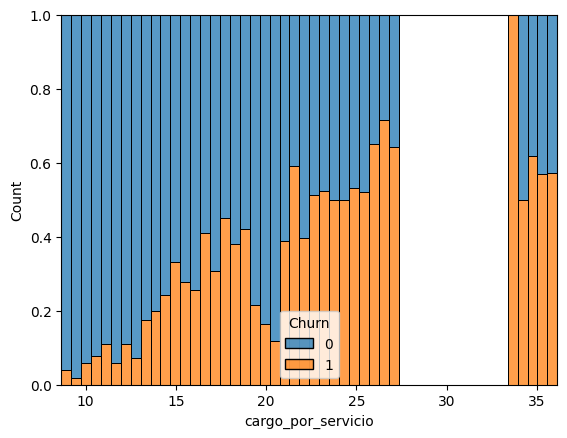



3.CHURN POR GRUPO DE TENURE
               mean  count
tenure_group              
0-12m         0.474   2186
13-24m        0.287   1024
25-48m        0.204   1594
49-72m        0.095   2239


4.CLIENTES DE ALTO VALOR
Umbral alto valor: $89.85/mes


/tmp/ipykernel_2785/1601695159.py:54: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_tenuregroup=df.groupby("tenure_group")["Churn"].agg(


In [184]:
# Feature 1: n_servicios_contratados
servicios_adicionales = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies",
    "MultipleLines"]
    #creación de variable
df["n_servicios_adicionales"] = (df[servicios_adicionales] == "Yes"
).sum(axis=1)
    #tabla de relación
churn_by_services=df.groupby("n_servicios_adicionales")["Churn"].agg(
    ['mean','count']).round(3)
print()
print('1.CHURN POR NUMERO DE SERVICIOS ADICIONALES')
print(churn_by_services)
print()

# Feature 2: costo mensual por servicio
  #conteo de productos incluyendo Internet/Phone service
df["n_productos"] = df["n_servicios_adicionales"] + (
    df["PhoneService"] == "Yes"
).astype(int) + (
    df["InternetService"] != "No"
).astype(int)

  # Evitar división por cero
df["cargo_por_servicio"] = (
    df["MonthlyCharges"] / df["n_productos"].clip(lower=1)
).round(2)

churn_por_cargo = (df.groupby("cargo_por_servicio")["Churn"]
    .mean()
    .reset_index())

sns.histplot(
    data=df,
    x="cargo_por_servicio",
    hue="Churn",
    multiple="fill",
    bins=(50))

print()
print('2.COSTO MENSUAL POR SERVICIO')
plt.show()
print()

# Feature 3: tenure group
bins   = [0, 12, 24, 48, 72]
labels = ["0-12m", "13-24m", "25-48m", "49-72m"]

df["tenure_group"] = pd.cut(df["tenure"],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True)
churn_by_tenuregroup=df.groupby("tenure_group")["Churn"].agg(
    ['mean','count']).round(3)


print()
print('3.CHURN POR GRUPO DE TENURE')
print(churn_by_tenuregroup)
print()

#Feature 4: clientes de alto valor
p75_month_charges = df["MonthlyCharges"].quantile(0.75)
df["is_high_value"] = (df["MonthlyCharges"] > p75_month_charges).astype(int)

print()
print('4.CLIENTES DE ALTO VALOR')
print(f"Umbral alto valor: ${p75_month_charges:.2f}/mes")

Caso 2 - Parte A
  
  3. Ingenieria de caracteristicas:

    3.1 numero de servicios adicionales contratados:
      Esta variable puede ser interesante ya que, entre más servicios extra se contraten de la empresa, se podría argumentar que de cierta forma el cliente forma más parte del ecosistema de servicios creado por ella. Si, por ejemplo, hay beneficios o utilidades exclusivos entre los servicios de la empresa puede que sea mas dificil para el cliente renunciar a el. En resumen, entre más servicios tenga contratado el cliente, más costoso es hacer un cambio de operador.

      Se evidencia una caida sostenida en la tasa de churn a partir de los 2 servicios contratados.

    3.2 costo mensual por servicio:
      A partir del numero de servicios contratados podemos calcular cuanto paga mensualmente cada cliente respecto al numero de servicios que tiene contratado. Un cliente que paga más por menos servicios puede encontrar un sustituto más sencillo.

      Se observa que, en general, los clientes que experimentan un cargo por servicio mayor suelen tener un porcentaje de abandono mayor.

    3.3 tenure group:
      Al momento de diseñar una campaña se necesita identificar grupos. Tenure como variable continua no permite esto, por esta razón es util dividirlo en grupos claros a los que se pueda dirigir. Esto ya se demostró visualmente previamente.

      Como ser observó, el ratio de cancelación tiene una caida dramatica y sostenida pasado el primer año.

    3.4 cliente de alto valor:
      Perder un cliente con un valor de pago mensual relativamente alto implica un costo de oportunidad alto para la empresa. En el caso en que se tuvieran que dedicar recursos a una porción los clientes con alto porcentaje de cancelar, sería util poder dirigir una cantidad de recursos relativos al valor en ingresos que representa cada cliente. Esto permitiría priorizar a los clientes cuyo impacto economico es mayor.

      Esta medida no tiene proposito como predictora, si no como variable para dar prioridad a clientes especificos.

In [186]:
#Modelo de regresión
#Verificación de supuestos: multicolinealidad
df_vif = pd.get_dummies(
    df[["tenure", "n_servicios_adicionales", "Contract"]],
    columns=["Contract"],
    drop_first=True
).astype(float)

# Añadir constante para el intercepto
df_vif["const"] = 1.0

vif = pd.DataFrame({
    "variable": df_vif.columns,
    "VIF": [
        variance_inflation_factor(df_vif.values, i)
        for i in range(df_vif.shape[1])
    ]
}).sort_values("VIF", ascending=False)

Presenta_Colinealidad=[]
for index, row in vif.iterrows():
  if row['VIF'] < 5:
    Presenta_Colinealidad.append('No')
  elif row['VIF'] > 5:
    Presenta_Colinealidad.append('Si')
  else:
    Presenta_Colinealidad.append('Marginal') # For VIF == 5

# Add the new column to the vif DataFrame for display
vif['Presenta_Colinealidad'] = Presenta_Colinealidad

print('TEST DE MULTICOLINEALIDAD')
print(vif)
print()

df_modelo = pd.get_dummies(
    df[["tenure", "n_servicios_adicionales", "Contract", "Churn"]],
    columns=["Contract"],
    drop_first=True
).astype(float)

X = df_modelo.drop(columns=["Churn"])
y = df_modelo["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Entrenar
X_train_sm = sm.add_constant(X_train)
X_test_sm  = sm.add_constant(X_test)

modelo_logit = sm.Logit(y_train, X_train_sm).fit()

# Métricas
pseudo_r2   = modelo_logit.prsquared
y_prob_test = modelo_logit.predict(X_test_sm)
brier_score = np.mean((y_prob_test - y_test) ** 2)

print(f"Pseudo R² McFadden : {pseudo_r2:.4f}")
print(f"Brier Score        : {brier_score:.4f}")
print(f"\n{modelo_logit.summary()}")

TEST DE MULTICOLINEALIDAD
                  variable       VIF Presenta_Colinealidad
4                    const  3.156537                    No
0                   tenure  2.364708                    No
3        Contract_Two year  1.952232                    No
1  n_servicios_adicionales  1.402096                    No
2        Contract_One year  1.385582                    No

Optimization terminated successfully.
         Current function value: 0.463058
         Iterations 8
Pseudo R² McFadden : 0.1997
Brier Score        : 0.1543

                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                 5634
Model:                          Logit   Df Residuals:                     5629
Method:                           MLE   Df Model:                            4
Date:                Sat, 13 Jun 2026   Pseudo R-squ.:                  0.1997
Time:                        18:57:08   Log-Likelihood:          

Caso 2 - Parte B
  1. Modelo de regresión:
    
    1.1 Tipo de modelo:
      De acuerdo con lo mencionado previamente se estimará un modelo logistico que determine la probabilidad de que el cliente abandone. Se tomará como variable dependiente Churn y las variables deterministicas serán lead_time como variable continua, el tipo de contrato y la cantidad de servicios adicionales contratados.

    1.2 Supuestos:
      La variable Churn es dicotomica y sus categorías mutuamente excluyentes, razón por la que es perfecta para un modelo logistico. La cantidad de observaciones es más que suficiente y las variables no presentan multicolinealidad de acuerdo con el coeficiente VIF. Cada una de las variables evalua dimensiones diferentes que afectan el Churn: antiguedad, profundidad de uso y tipo de relación contractual.

    1.3 Modelo:
      Del modelo obtenemos que todas las variables son estadisticamente significativas, es decir, que se asocian con el Churn. Se concluye que:
      - Cada mes adicional de tenure se asocia con una probabilidad de Churn reducida en un 2%
      - Los contratos de mayor duración reducen la tasa de Churn de los clientes.